<a href="https://colab.research.google.com/github/TanviAshokKadge/DS/blob/main/DS_Pract_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# KNN Algorithm for breast cancer detection**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
sns.set()

In [ ]:
breast_cancer_data = load_breast_cancer()
x_df = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)
x_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X_df = x_df[['mean area','mean compactness']]
X_df.head()

,mean area,mean compactness
0,1001.0,0.27760
1,1326.0,0.07864
2,1203.0,0.15990
3,386.1,0.28390
4,1297.0,0.13280


In [ ]:
Y_df = pd.Categorical.from_codes(breast_cancer_data.target, breast_cancer_data.target_names)
print(Y_df)

['malignant', 'malignant', 'malignant', 'malignant', 'malignant', ..., 'malignant', 'malignant', 'malignant', 'malignant', 'benign']
Length: 569
Categories (2, object): ['malignant', 'benign']


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_df, Y_df, random_state=1)

In [ ]:
# knn is the model object
# Creating knn model using KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, Y_train)

KNeighborsClassifier(metric='euclidean')

<Axes: xlabel='mean area', ylabel='mean compactness'>

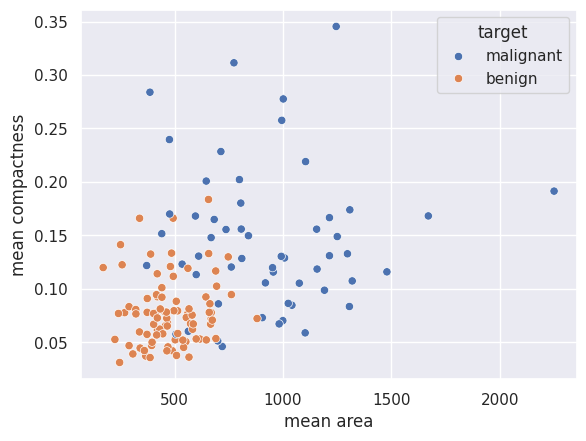

In [ ]:
# Convert Y_test into a Pandas Series and align index with X_test
Y_test_series = pd.Series(Y_test, index=X_test.index, name='target')

# Combine feature data and target column
combined_df = pd.concat([X_test, Y_test_series], axis=1)

# Create scatter plot
sns.scatterplot(x='mean area', y='mean compactness', hue='target', data=combined_df)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score

# Predict
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(Y_test, y_pred, pos_label='malignant')
print("Precision:", precision)

Accuracy: 0.8461538461538461
Precision: 0.8235294117647058
